In [2]:
import pandas as pd 
from transformers import AutoTokenizer, AutoModelForSequenceClassification 
import torch
from torch.nn.functional import softmax
from tqdm import tqdm

In [3]:
#  Load FinBERT model and tokenizer
model_name = "ProsusAI/finbert"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name)

c:\Users\OKIO\Desktop\mood2market\.venv\lib\site-packages\huggingface_hub\file_download.py:942: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


In [4]:
# Use GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu') 
model = model.to(device).eval()

In [8]:
# Load cleaned news data
news_path = r"C:\Users\OKIO\Desktop\mood2market\Backend\Data\raw\news_raw_update.csv"
news_df = pd.read_csv(news_path)

In [9]:
# Sentiment function
def analyze_sentiment(text):
    """Return FinBERT sentiment scores (pos, neg, neu)."""
    if not isinstance(text, str) or text.strip() == "":
        return 0.33, 0.33, 0.33 # default neutral
    inputs = tokenizer(text[:512], return_tensors='pt', truncation=True, padding=True)
    inputs = {k: v.to(device) for k, v in inputs.items()}
    with torch.no_grad():
      outputs = model(**inputs)
      probs = softmax(outputs.logits, dim=1)[0].cpu().numpy()
    return float(probs[0]), float(probs[1]), float(probs[2])
    


In [10]:
# Apply sentiment analysis
news_df[['sentiment_positive','sentiment_negative','sentiment_neutral']] = [
    analyze_sentiment(text) for text in tqdm(news_df['text_for_sentiment'], desc="Analyzing news sentiment")
]

Analyzing news sentiment:   0%|          | 0/2790 [00:00<?, ?it/s]

Analyzing news sentiment: 100%|██████████| 2790/2790 [04:59<00:00,  9.31it/s]


In [11]:
# Net sentiment score & label
news_df['sentiment_score'] = news_df['sentiment_positive'] - news_df['sentiment_negative']
news_df['sentiment_label'] = news_df['sentiment_score'].apply(lambda x: 'positive' if x > 0.1 else ('negative' if x < -0.1 else 'neutral'))

In [12]:
# Aggregate daily sentiment
news_df['date'] = pd.to_datetime(news_df['date'])
daily_news= news_df.groupby('date').agg({
    'sentiment_score': 'mean',
    'sentiment_positive': 'mean',
    'sentiment_negative': 'mean',
    'sentiment_neutral': 'mean',
    'text_for_sentiment': 'count'
}).rename(columns={'text_for_sentiment': 'news_count'}).reset_index()

In [14]:
# ── MERGE WITH EXISTING AND SAVE ──────────────────────────────────────────────

import os

daily_news_path = r"C:\Users\OKIO\Desktop\mood2market\Backend\Data\processed\daily_news_sentiment.csv"
news_path       = r"C:\Users\OKIO\Desktop\mood2market\Backend\Data\processed\news_with_sentiment.csv"

# --- daily_news_sentiment.csv ---
if os.path.exists(daily_news_path):
    existing_daily = pd.read_csv(daily_news_path, parse_dates=["date"])
    combined_daily = (
        pd.concat([existing_daily, daily_news], ignore_index=True)
        .drop_duplicates(subset="date", keep="last")
        .sort_values("date")
        .reset_index(drop=True)
    )
    print(f"daily_news: {len(existing_daily)} existing + {len(daily_news)} new = {len(combined_daily)} rows")
else:
    combined_daily = daily_news
    print("No existing daily_news file found, saving new only")

combined_daily.to_csv(daily_news_path, index=False)

# --- news_with_sentiment.csv ---
if os.path.exists(news_path):
    existing_news = pd.read_csv(news_path, parse_dates=["date"])
    combined_news = (
        pd.concat([existing_news, news_df], ignore_index=True)
        .drop_duplicates(subset="date", keep="last")
        .sort_values("date")
        .reset_index(drop=True)
    )
    print(f"news_with_sentiment: {len(existing_news)} existing + {len(news_df)} new = {len(combined_news)} rows")
else:
    combined_news = news_df
    print("No existing news_with_sentiment file found, saving new only")

combined_news.to_csv(news_path, index=False)

print("Done. Files updated.")

daily_news: 400 existing + 45 new = 400 rows
news_with_sentiment: 400 existing + 2790 new = 400 rows
Done. Files updated.


In [15]:
print("News sentiment analysis complete. Files saved.")

News sentiment analysis complete. Files saved.


In [16]:
#for reddit sentiment
reddit_path = r"C:\Users\OKIO\Desktop\mood2market\Backend\Data\processed\main Data\second_redditclean.csv"
reddit_df = pd.read_csv(reddit_path)

In [17]:
#apply sentiment for reddit
reddit_df[['sentiment_positive','sentiment_negative','sentiment_neutral']] = [
    analyze_sentiment(text) for text in tqdm(reddit_df['text_for_sentiment'], desc="Analyzing reddit sentiment")
]

Analyzing reddit sentiment: 100%|██████████| 229/229 [00:47<00:00,  4.87it/s]


In [18]:
# Net sentiment score & label for reddit
reddit_df['sentiment_score'] = reddit_df['sentiment_positive'] - reddit_df['sentiment_negative']
reddit_df['sentiment_label'] = reddit_df['sentiment_score'].apply(lambda x: 'positive' if x > 0.1 else ('negative' if x < -0.1 else 'neutral'))

In [19]:
#aggregate daily sentiment for reddit
reddit_df['date'] = pd.to_datetime(reddit_df['date'])
daily_reddit= reddit_df.groupby('date').agg({
    'sentiment_score': 'mean',
    'sentiment_positive': 'mean',
    'sentiment_negative': 'mean',
    'sentiment_neutral': 'mean',
    'text_for_sentiment': 'count'
}).rename(columns={'text_for_sentiment': 'reddit_count'}).reset_index()

In [20]:
#save reddit results

daily_reddit_path = r"C:\Users\OKIO\Desktop\mood2market\Backend\Data\processed\daily_reddit_sentiment.csv"
reddit_path       = r"C:\Users\OKIO\Desktop\mood2market\Backend\Data\processed\reddit_with_sentiment.csv"

# --- daily_reddit_sentiment.csv ---
if os.path.exists(daily_reddit_path):
    existing_daily = pd.read_csv(daily_reddit_path, parse_dates=["date"])
    combined_daily = (
        pd.concat([existing_daily, daily_reddit], ignore_index=True)
        .drop_duplicates(subset="date", keep="last")
        .sort_values("date")
        .reset_index(drop=True)
    )
    print(f"daily_reddit: {len(existing_daily)} existing + {len(daily_reddit)} new = {len(combined_daily)} rows")
else:
    combined_daily = daily_reddit
    print("No existing daily_reddit file found, saving new only")

combined_daily.to_csv(daily_reddit_path, index=False)

# --- reddit_with_sentiment.csv ---
if os.path.exists(reddit_path):
    existing_reddit = pd.read_csv(reddit_path, parse_dates=["date"])
    combined_reddit = (
        pd.concat([existing_reddit, reddit_df], ignore_index=True)
        .drop_duplicates(subset="date", keep="last")
        .sort_values("date")
        .reset_index(drop=True)
    )
    print(f"reddit_with_sentiment: {len(existing_reddit)} existing + {len(reddit_df)} new = {len(combined_reddit)} rows")
else:
    combined_reddit = reddit_df
    print("No existing reddit_with_sentiment file found, saving new only")

combined_reddit.to_csv(reddit_path, index=False)

print("Reddit sentiment analysis complete. Files updated.")

daily_reddit: 160 existing + 27 new = 187 rows
reddit_with_sentiment: 1389 existing + 229 new = 187 rows
Reddit sentiment analysis complete. Files updated.


In [21]:
#visualization of using a different tokenizer
from transformers import BertTokenizer 
reddit_df = pd.read_csv("C:\\Users\\OKIO\\Desktop\\mood2market\\Backend\\Data\\processed\\reddit_clean.csv") # Initialize FinBERT tokenizer
tokenizer = BertTokenizer.from_pretrained("yiyanghkust/finbert-tone") # Compute token lengths for each post
token_lengths = [len(tokenizer(str(text))['input_ids']) for text in reddit_df['text_for_sentiment']]

c:\Users\OKIO\Desktop\mood2market\.venv\lib\site-packages\huggingface_hub\file_download.py:942: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


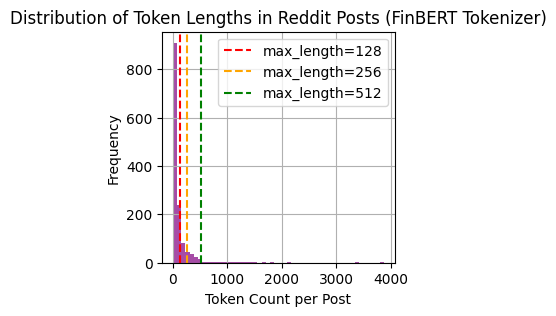

In [22]:
# Plot histogram of token lengths
import matplotlib.pyplot as plt
pd.Series(token_lengths).hist(bins=50, figsize=(3,3), color="purple", alpha=0.7)
 # Overlay cutoff lines
plt.axvline(128, color='red', linestyle='--', label='max_length=128') 
plt.axvline(256, color='orange', linestyle='--', label='max_length=256')
plt.axvline(512, color='green', linestyle='--', label='max_length=512') 
plt.title("Distribution of Token Lengths in Reddit Posts (FinBERT Tokenizer)") 
plt.xlabel("Token Count per Post") 
plt.ylabel("Frequency") 
plt.legend() 
plt.show()

In [ ]:
# y‑axis (frequency) shows how many Reddit posts fall into each token length bucket.


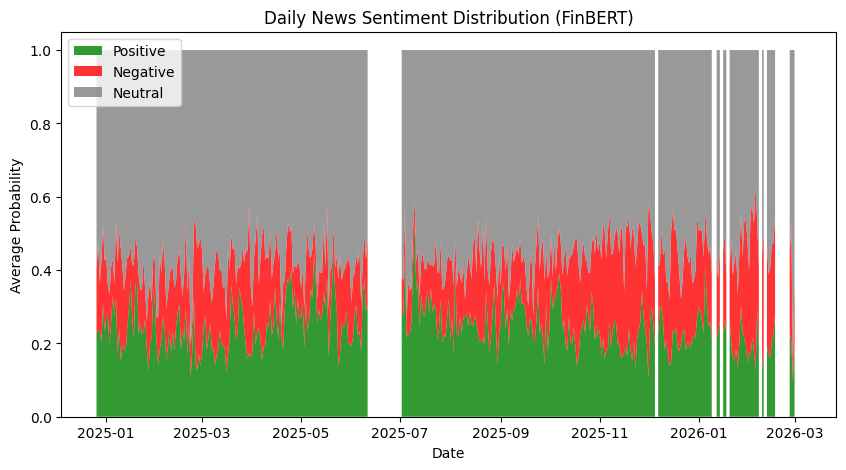

In [23]:
import seaborn as sns
#visualization of news sentiment distribution
df_visualize_news_output = pd.read_csv(r"C:\Users\OKIO\Desktop\mood2market\Backend\Data\processed\daily_news_sentiment.csv")
df_visualize_news_output['date'] = pd.to_datetime(df_visualize_news_output['date'])

full_range = pd.date_range(start=df_visualize_news_output['date'].min(), end=df_visualize_news_output['date'].max(), freq="D")

# Aggregate daily averages 
daily_probs = df_visualize_news_output.groupby('date')[['sentiment_positive','sentiment_negative','sentiment_neutral']].mean()
daily_probs = daily_probs.reindex(full_range)

# Plotting
plt.figure(figsize=(10,5))
plt.stackplot(daily_probs.index, daily_probs['sentiment_positive'], daily_probs['sentiment_negative'], daily_probs['sentiment_neutral'],
                labels=['Positive', 'Negative', 'Neutral'], colors=['green', 'red', 'gray'], alpha=0.8)
plt.title("Daily News Sentiment Distribution (FinBERT)")
plt.xlabel("Date")
plt.ylabel("Average Probability")
plt.legend(loc='upper left')
plt.show()

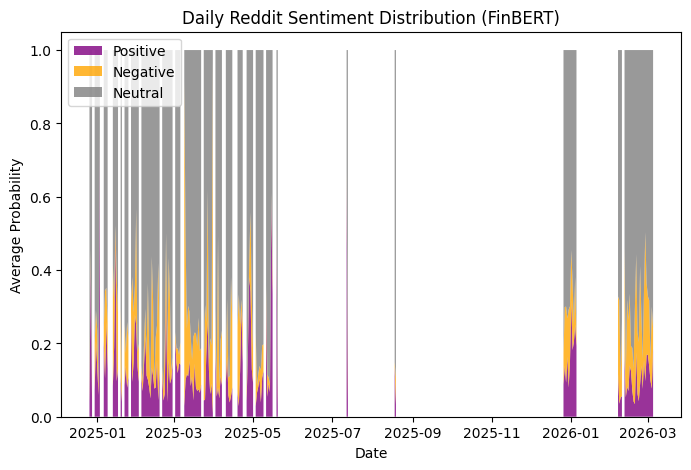

In [24]:
#visualization of reddit sentiment distribution
df_visualize_reddit_output = pd.read_csv(r"C:\Users\OKIO\Desktop\mood2market\Backend\Data\processed\daily_reddit_sentiment.csv")
df_visualize_reddit_output['date'] = pd.to_datetime(df_visualize_reddit_output['date'])

full_range = pd.date_range(start=df_visualize_reddit_output['date'].min(), end=df_visualize_reddit_output['date'].max(), freq="D")

# Aggregate daily averages 
daily_probs = df_visualize_reddit_output.groupby('date')[['sentiment_positive','sentiment_negative','sentiment_neutral']].mean()
daily_probs = daily_probs.reindex(full_range)

# Plotting
plt.figure(figsize=(8,5))
plt.stackplot(daily_probs.index, daily_probs['sentiment_positive'], daily_probs['sentiment_negative'], daily_probs['sentiment_neutral'],
                labels=['Positive', 'Negative', 'Neutral'], colors=['purple', 'orange', 'gray'], alpha=0.8)
plt.title("Daily Reddit Sentiment Distribution (FinBERT)")
plt.xlabel("Date")
plt.ylabel("Average Probability")
plt.legend(loc='upper left')
plt.show()

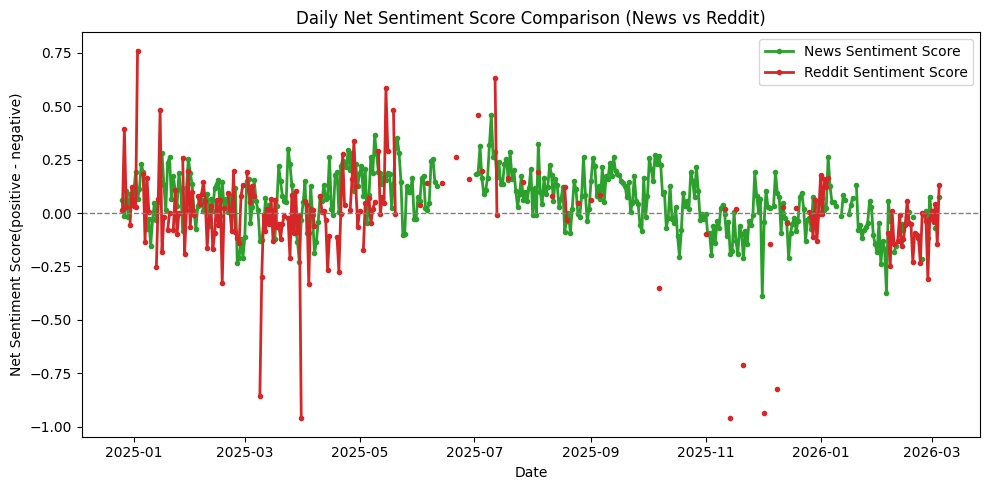

In [25]:
#comparing news and reddit sentiment distributions over time
news_df = pd.read_csv(r"C:\Users\OKIO\Desktop\mood2market\Backend\Data\processed\daily_news_sentiment.csv") 
reddit_df = pd.read_csv(r"C:\Users\OKIO\Desktop\mood2market\Backend\Data\processed\daily_reddit_sentiment.csv")

news_df['date'] = pd.to_datetime(news_df['date'])
reddit_df['date'] = pd.to_datetime(reddit_df['date'])

full_range = pd.date_range( start=min(news_df['date'].min(), reddit_df['date'].min()), end=max(news_df['date'].max(), reddit_df['date'].max()), freq="D" )
#Agregate daily averages for news and reddit
news_daily = news_df.groupby('date')[['sentiment_positive','sentiment_negative','sentiment_neutral']].mean().reindex(full_range)
reddit_daily = reddit_df.groupby('date')[['sentiment_positive','sentiment_negative','sentiment_neutral']].mean().reindex(full_range)

#compute net sentiment scores
news_daily['sentiment_score'] = news_daily['sentiment_positive'] - news_daily['sentiment_negative']
reddit_daily['sentiment_score'] = reddit_daily['sentiment_positive'] - reddit_daily['sentiment_negative']
# Plotting
plt.figure(figsize=(10,5))
plt.plot(news_daily.index, news_daily['sentiment_score'], label='News Sentiment Score', color='tab:green', linewidth=2, marker='o', markersize=3)
plt.plot(reddit_daily.index, reddit_daily['sentiment_score'], label='Reddit Sentiment Score', color='tab:red', linewidth=2, marker='o', markersize=3)
plt.axhline(0, color='gray', linestyle='--', linewidth=1)
plt.title("Daily Net Sentiment Score Comparison (News vs Reddit)") 
plt.xlabel("Date")
plt.ylabel("Net Sentiment Score(positive - negative)")
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

In [28]:
#visualization of btc price vs sentiment
import pandas as pd
import matplotlib.pyplot as plt

#Load merged dataset (BTC + News + Reddit sentiment)
data = pd.read_csv(r"C:\Users\OKIO\Desktop\mood2market\Backend\Data\processed\main Data\new_merged.csv")
# Convert date column to datetime
data['date'] = pd.to_datetime(data['date'])

#Find sentiment event days
# News sentiment
neg_news = data.loc[data['sentiment_score_x'].idxmin()]
pos_news = data.loc[data['sentiment_score_x'].idxmax()]


# Reddit sentiment
neg_reddit = data.loc[data['sentiment_score_y'].idxmin()]
pos_reddit = data.loc[data['sentiment_score_y'].idxmax()]


print("News Negative:", neg_news['date'], neg_news['sentiment_score_x'])
print("News Positive:", pos_news['date'], pos_news['sentiment_score_x'])
print("Reddit Negative:", neg_reddit['date'], neg_reddit['sentiment_score_y'])
print("Reddit Positive:", pos_reddit['date'], pos_reddit['sentiment_score_y'])




News Negative: 2025-12-01 00:00:00 -0.386208180580414
News Positive: 2025-07-10 00:00:00 0.4584695551613414
Reddit Negative: 2025-11-14 00:00:00 -0.961616937071085
Reddit Positive: 2025-01-03 00:00:00 0.7604866828769445


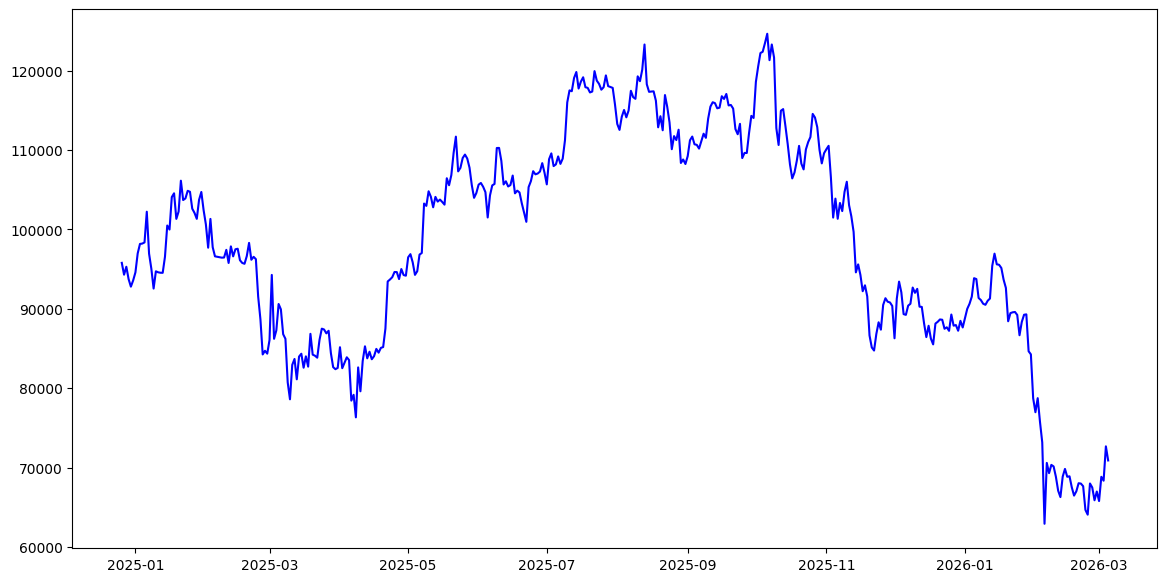

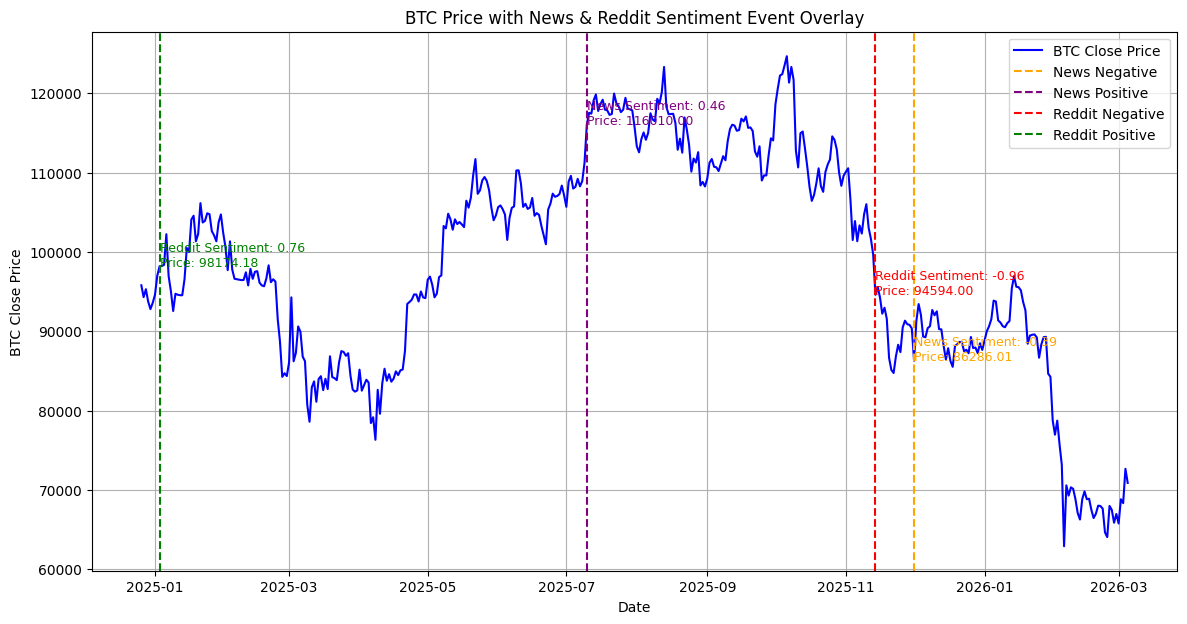

In [29]:
# 3. Plot BTC close price with sentiment event overlay
plt.figure(figsize=(14,7))
plt.plot(data['date'], data['close'], label='BTC Close Price', color='blue')

# 3. Plot BTC close price with sentiment event overlay
plt.figure(figsize=(14,7))
plt.plot(data['date'], data['close'], label='BTC Close Price', color='blue')

# Highlight News sentiment events
plt.axvline(x=neg_news['date'], color='orange', linestyle='--', label='News Negative')
plt.text(neg_news['date'], neg_news['close'],
         f"News Sentiment: {neg_news['sentiment_score_x']:.2f}\nPrice: {neg_news['close']:.2f}",
         color='orange', fontsize=9)

plt.axvline(x=pos_news['date'], color='purple', linestyle='--', label='News Positive')
plt.text(pos_news['date'], pos_news['close'],
         f"News Sentiment: {pos_news['sentiment_score_x']:.2f}\nPrice: {pos_news['close']:.2f}",
         color='purple', fontsize=9)

# Highlight Reddit sentiment events
plt.axvline(x=neg_reddit['date'], color='red', linestyle='--', label='Reddit Negative')
plt.text(neg_reddit['date'], neg_reddit['close'],
         f"Reddit Sentiment: {neg_reddit['sentiment_score_y']:.2f}\nPrice: {neg_reddit['close']:.2f}",
         color='red', fontsize=9)

plt.axvline(x=pos_reddit['date'], color='green', linestyle='--', label='Reddit Positive')
plt.text(pos_reddit['date'], pos_reddit['close'],
         f"Reddit Sentiment: {pos_reddit['sentiment_score_y']:.2f}\nPrice: {pos_reddit['close']:.2f}",
         color='green', fontsize=9)

plt.legend()
plt.title("BTC Price with News & Reddit Sentiment Event Overlay")
plt.xlabel("Date")
plt.ylabel("BTC Close Price")
plt.grid(True)
plt.show()

In [ ]:
# Pie chart — overall news sentiment distribution (positive / negative / neutral)
import matplotlib.pyplot as plt
import pandas as pd

# Load the daily news sentiment file
df_pie = pd.read_csv(r"C:\Users\OKIO\Desktop\mood2market\Backend\Data\processed\daily_news_sentiment.csv")

# Use the mean probability of each class across all days as the slice sizes
pos_mean = df_pie['sentiment_positive'].mean()
neg_mean = df_pie['sentiment_negative'].mean()
neu_mean = df_pie['sentiment_neutral'].mean()

labels  = ['Positive', 'Negative', 'Neutral']
sizes   = [pos_mean, neg_mean, neu_mean]
colors  = ['#2ca02c', '#d62728', '#7f7f7f']
explode = (0.04, 0.04, 0.04)  # slight separation on all slices

fig, ax = plt.subplots(figsize=(6, 6))
wedges, texts, autotexts = ax.pie(
    sizes,
    labels=labels,
    colors=colors,
    autopct='%1.1f%%',
    startangle=140,
    explode=explode,
    wedgeprops=dict(edgecolor='white', linewidth=1.5)
)

# Style the percentage labels
for autotext in autotexts:
    autotext.set_fontsize(12)
    autotext.set_fontweight('bold')
    autotext.set_color('white')

ax.set_title("News Sentiment Distribution (FinBERT)\nOverall Percentage of Positive, Negative and Neutral",
             fontsize=13, pad=20)

plt.tight_layout()
plt.savefig(r"C:\Users\OKIO\Desktop\mood2market\Backend\models\plot_news_sentiment_pie.png",
            dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print(f"Positive: {pos_mean*100:.1f}%  |  Negative: {neg_mean*100:.1f}%  |  Neutral: {neu_mean*100:.1f}%")

NameError: name 'pd' is not defined